[2024-09-20 14:29:21,158][connect:74] Socket connected


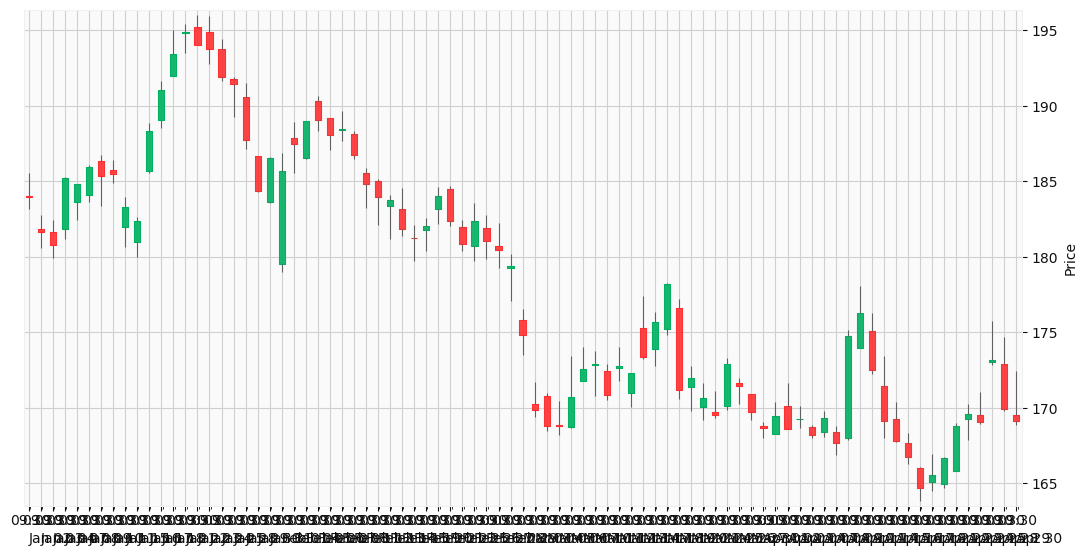

In [1]:
import sys, os, datetime, time, warnings
sys.path.append('../xtb')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf
from datetime import datetime, timedelta
from DataCollectorXtb import DataCollectorXtb 

ticks = []
tlabs = []
mitks = []
milab = []

collector=DataCollectorXtb(symbol='AAPL.US_4', start='2024-01-01', end='2024-05-01', period='1D',
                spread_col=False, cols_to_save=['Date','Open', 'High', 'Low','Close'])

df = collector.data

df.columns = ['Date', 'Open', 'High', 'Low', 'Close']

df.set_index('Date')
df.index = pd.to_datetime(collector.data.Date)

dates = sorted(list(set([d.date() for d in df.index])))

for d1 in dates:

    # Major Ticks:
    d2 = d1 + timedelta(days=1)
    ts = df.loc[d1:d2].index[0]
    ticks.append(df.index.get_loc(ts))
    # line feed at beginning of label so it appears a lower below the x-axis:
    tlabs.append('\n'+d1.strftime('%b %d'))

    # Minor Ticks:
    mitks.append(ticks[-1]+0.1)
    milab.append('09:30')
    ts = df.loc[str(d1)+' 13:00':d2].index[0]
    mitks.append(df.index.get_loc(ts))
    milab.append('13:00')

fig, axlist = mpf.plot(df,type='candle',xrotation=0,style='yahoo',tight_layout=True,returnfig=True,figratio=(2,1))

axlist[-2].set_xticks(ticks)
axlist[-2].set_xticklabels(tlabs, ha='left')
axlist[-2].set_xticks(mitks,minor=True)
axlist[-2].set_xticklabels(milab, ha='center', minor=True, rotation=0)

mpf.show()
